# Tahap 2 — Prapemrosesan dan Rekayasa Kanal

Verifikasi modul [`src/preprocessing.py`](../src/preprocessing.py), mengikuti Subbab 3.4 naskah proposal.

Notebook ini menemukan **tiga hal yang mengoreksi hasil Tahap 1** dan menentukan rancangan seluruh
pipeline. Ketiganya baru terlihat setelah data mentah diperiksa pada tingkat timestamp, bukan pada
tingkat ringkasan.

In [1]:
import sys
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from preprocessing import (
    muat_berkas, pecah_segmen, muat_dataset, Normalisasi,
    simpan_cache, muat_cache, KANAL_MODEL, NAMA_TUGAS, FS_ASLI, FS_TARGET, DURASI_MIN_DETIK,
)

AKAR = Path("../data/raw/uci395/extracted")
berkas = (sorted((AKAR / "hw_dataset/control").glob("*.txt"))
          + sorted((AKAR / "hw_dataset/parkinson").glob("*.txt"))
          + sorted((AKAR / "new_dataset/parkinson").glob("*.txt")))
print(f"{len(berkas)} berkas subjek")

77 berkas subjek


## 1. Koreksi frekuensi sampling

Tahap 1 melaporkan 142,86 Hz, dihitung dari **median** selisih timestamp. Angka itu keliru.
Distribusi selisih timestamp bersifat bimodal, sehingga median jatuh tepat pada salah satu puncak
dan mengabaikan puncak lainnya.

In [2]:
dt_semua = []
for f in berkas:
    a = muat_berkas(f)
    for tid in np.unique(a[:, 6]):
        d = np.diff(a[a[:, 6] == tid][:, 5])
        dt_semua.extend(d[(d > 0) & (d < 100)].tolist())
dt_semua = np.array(dt_semua)

nilai, jumlah = np.unique(dt_semua, return_counts=True)
urut = np.argsort(-jumlah)[:5]
print("distribusi selisih timestamp:")
for i in urut:
    print(f"  {nilai[i]:4.0f} ms -> {jumlah[i]:7,} ({jumlah[i]/len(dt_semua)*100:5.2f}%)")

print()
print(f"median  = {np.median(dt_semua):.3f} ms -> {1000/np.median(dt_semua):7.2f} Hz   (dilaporkan Tahap 1, KELIRU)")
print(f"rata2   = {dt_semua.mean():.3f} ms -> {1000/dt_semua.mean():7.2f} Hz   (benar, dipakai sebagai FS_ASLI)")

distribusi selisih timestamp:
     7 ms -> 301,769 (57.55%)
     9 ms -> 209,032 (39.86%)
     8 ms ->  11,917 ( 2.27%)
    10 ms ->   1,478 ( 0.28%)
    14 ms ->      30 ( 0.01%)

median  = 7.000 ms ->  142.86 Hz   (dilaporkan Tahap 1, KELIRU)
rata2   = 7.842 ms ->  127.52 Hz   (benar, dipakai sebagai FS_ASLI)


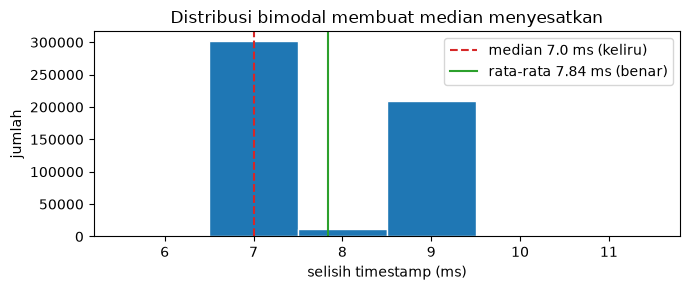

In [3]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(dt_semua, bins=np.arange(5.5, 12.5, 1), edgecolor="white")
ax.axvline(np.median(dt_semua), color="tab:red", ls="--", label=f"median {np.median(dt_semua):.1f} ms (keliru)")
ax.axvline(dt_semua.mean(), color="tab:green", ls="-", label=f"rata-rata {dt_semua.mean():.2f} ms (benar)")
ax.set_xlabel("selisih timestamp (ms)"); ax.set_ylabel("jumlah"); ax.legend()
ax.set_title("Distribusi bimodal membuat median menyesatkan")
plt.tight_layout(); plt.show()

Konsekuensinya bukan sekadar angka di naskah. Selisih timestamp yang **tidak seragam** berarti
turunan (kecepatan, percepatan, jerk) tidak boleh dihitung langsung dari data mentah: hasilnya akan
mengandung derau yang berasal dari jitter pencatatan waktu, bukan dari gerak tangan. Resampling ke
grid seragam menjadi wajib, bukan opsional.

## 2. Lompatan timestamp mundur

Empat belas dari 202 rekaman memuat timestamp yang melompat mundur. Pemeriksaan konteksnya
menunjukkan ini bukan kerusakan data acak, melainkan batas antara dua sesi perekaman yang tersambung
dalam satu berkas.

In [4]:
a = muat_berkas(AKAR / "hw_dataset/parkinson/P_27110003.txt")
s = a[a[:, 6] == 2]
i = np.where(np.diff(s[:, 5]) <= 0)[0][0]
print("P_27110003, Test ID 2, di sekitar lompatan mundur pertama:")
print(f"{'baris':>7} {'timestamp':>12} {'x':>6} {'y':>6} {'tekanan':>8}")
for j in range(i - 2, i + 4):
    tanda = "  <-- lompat mundur" if j == i + 1 else ""
    print(f"{j:7d} {s[j,5]:12.0f} {s[j,0]:6.0f} {s[j,1]:6.0f} {s[j,3]:8.0f}{tanda}")

P_27110003, Test ID 2, di sekitar lompatan mundur pertama:
  baris    timestamp      x      y  tekanan
   1242      7965874    296    235        0
   1243      7965883    296    234        0
   1244      7965892    296    234        0
   1245      7963705    296    234        2  <-- lompat mundur
   1246      7963714    296    234       12
   1247      7963723    296    234       25


Pada baris lompatan, waktu mundur 2187 ms sementara koordinat nyaris tidak berubah dan tekanan
berubah dari nol menjadi tidak nol. Pola ini konsisten dengan sesi perekaman baru yang dimulai, bukan
dengan pena yang melompat.

Tiap potongan kontinu karena itu diperlakukan sebagai **rekaman tersendiri**, bukan disambung.
Menyambungnya akan menciptakan transien buatan tepat pada besaran yang hendak diukur penelitian ini.
Membuang seluruh rekaman yang terfragmentasi juga tidak dilakukan, karena terlalu boros.

In [5]:
segmen = []
for f in berkas:
    a = muat_berkas(f)
    for tid in np.unique(a[:, 6]):
        blok = a[a[:, 6] == tid]
        potongan = pecah_segmen(blok[:, 5])
        for p in potongan:
            segmen.append({"tugas": NAMA_TUGAS[int(tid)], "n": len(p),
                           "durasi": (blok[p[-1], 5] - blok[p[0], 5]) / 1000.0,
                           "terfragmentasi": len(potongan) > 1})
seg = pd.DataFrame(segmen)

print(f"202 rekaman -> {len(seg)} segmen kontinu")
print(f"segmen yang berasal dari rekaman terpecah: {seg.terfragmentasi.sum()}")
print()
total = seg.durasi.sum()
disimpan = seg[seg.durasi >= DURASI_MIN_DETIK].durasi.sum()
print("Perbandingan dua strategi penanganan fragmentasi:")
print(f"  ambil segmen terpanjang saja : retensi terburuk 33,6% pada satu rekaman")
print(f"  tiap segmen jadi rekaman     : {disimpan/total*100:.1f}% durasi total dipertahankan")

202 rekaman -> 226 segmen kontinu
segmen yang berasal dari rekaman terpecah: 38

Perbandingan dua strategi penanganan fragmentasi:
  ambil segmen terpanjang saja : retensi terburuk 33,6% pada satu rekaman
  tiap segmen jadi rekaman     : 99.5% durasi total dipertahankan


Ambang durasi minimum 2,86 detik **diturunkan dari pita tremor**, bukan ditetapkan sembarang:
tremor terendah 3,5 Hz berarti satu siklus 286 ms, dan estimasi amplitudo pita yang stabil
membutuhkan sekitar sepuluh siklus. Segmen yang lebih pendek dari itu tidak dapat memberi estimasi
tremor yang bermakna, terlepas dari model apa pun yang dipakai.

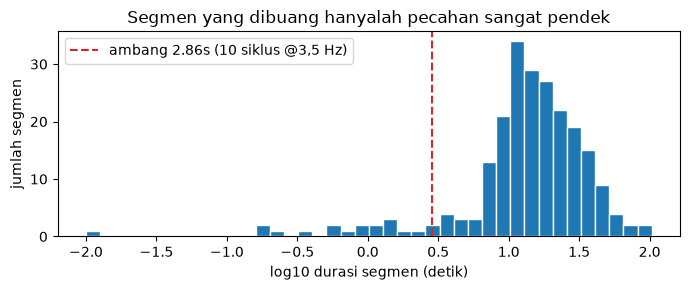

dibuang: 19 segmen, durasi 0.00s sampai 2.67s
kehilangan durasi total: 0.49%


In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(np.log10(seg.durasi.clip(lower=0.01)), bins=40, edgecolor="white")
ax.axvline(np.log10(DURASI_MIN_DETIK), color="tab:red", ls="--",
           label=f"ambang {DURASI_MIN_DETIK}s (10 siklus @3,5 Hz)")
ax.set_xlabel("log10 durasi segmen (detik)"); ax.set_ylabel("jumlah segmen")
ax.legend(); ax.set_title("Segmen yang dibuang hanyalah pecahan sangat pendek")
plt.tight_layout(); plt.show()

dibuang = seg[seg.durasi < DURASI_MIN_DETIK]
print(f"dibuang: {len(dibuang)} segmen, durasi {dibuang.durasi.min():.2f}s sampai {dibuang.durasi.max():.2f}s")
print(f"kehilangan durasi total: {dibuang.durasi.sum()/total*100:.2f}%")

## 3. Muat dataset penuh

Urutan pemrosesan: pisah per tugas, pecah di lompatan waktu, resampling ke grid seragam, baru
rekayasa kanal. Turunan sengaja dihitung **setelah** resampling agar selang waktunya konstan.

In [7]:
rek = muat_dataset(AKAR)
df = pd.DataFrame([r.meta() for r in rek])

print(f"{len(rek)} rekaman dari {df.subjek.nunique()} subjek "
      f"(PD {df[df.kelompok=='PD'].subjek.nunique()}, HC {df[df.kelompok=='HC'].subjek.nunique()})")
print("Naskah Subbab 3.3.1 menyebut 62 PD + 15 HC -> cocok.\n")

ringkas = df.groupby("nama_tugas").agg(
    n_rekaman=("subjek", "size"), n_subjek=("subjek", "nunique"),
    durasi_med=("durasi", "median"), durasi_min=("durasi", "min"), durasi_maks=("durasi", "max"),
).round(1)
display(ringkas)

207 rekaman dari 77 subjek (PD 62, HC 15)
Naskah Subbab 3.3.1 menyebut 62 PD + 15 HC -> cocok.



,n_rekaman,n_subjek,durasi_med,durasi_min,durasi_maks
nama_tugas,,,,,
DST,73,72,17.0,3.4,78.5
SST,77,76,18.1,3.7,103.1
STCP,57,54,12.9,4.8,58.4


Tidak semua subjek mengerjakan seluruh tugas. STCP, yang menjadi tugas analisis primer
(Subbab 3.6.7), hanya tersedia pada sebagian subjek. Ini butir G7 pada Lampiran C dan perlu
dinyatakan sebagai keterbatasan, bukan ditutupi.

In [8]:
pivot = df.pivot_table(index="subjek", columns="nama_tugas", values="n_sampel",
                       aggfunc="count", fill_value=0)
kelompok = df.groupby("subjek").kelompok.first()
lengkap = (pivot > 0).sum(axis=1)

print("kelengkapan tugas per subjek:")
for n in sorted(lengkap.unique(), reverse=True):
    s = lengkap[lengkap == n].index
    print(f"  {n} tugas: {len(s):2d} subjek  (PD {sum(kelompok[s]=='PD'):2d}, HC {sum(kelompok[s]=='HC'):2d})")
print()
punya = pivot["STCP"] > 0
ada, absen = punya[punya].index, punya[~punya].index
print("ketersediaan STCP (tugas analisis primer):")
print(f"  ada   : {len(ada):2d} subjek (PD {sum(kelompok[ada]=='PD')}, HC {sum(kelompok[ada]=='HC')})")
print(f"  absen : {len(absen):2d} subjek (PD {sum(kelompok[absen]=='PD')}, HC {sum(kelompok[absen]=='HC')})")

kelengkapan tugas per subjek:
  3 tugas: 49 subjek  (PD 42, HC  7)
  2 tugas: 27 subjek  (PD 19, HC  8)
  1 tugas:  1 subjek  (PD  1, HC  0)

ketersediaan STCP (tugas analisis primer):
  ada   : 54 subjek (PD 47, HC 7)
  absen : 23 subjek (PD 15, HC 8)


## 4. Pencilan pada kanal turunan

Kanal turunan memuat pencilan ekstrem. Sebelum memutuskan penanganannya, perlu dipastikan dulu
apakah pencilan itu gerak tangan sungguhan atau artefak sensor — karena keduanya menuntut perlakuan
yang berlawanan.

In [9]:
X = np.concatenate([r.kanal for r in rek])
tekanan = np.concatenate([r.tekanan_mentah for r in rek])
persen = [50, 90, 99, 99.9, 100]
display(pd.DataFrame({"kanal": KANAL_MODEL,
                      **{f"p{p}": np.percentile(np.abs(X), p, axis=0) for p in persen}}).set_index("kanal"))

jarak = np.linalg.norm(X[:, :2], axis=1)
besar = jarak > 50
print(f"langkah > 50 piksel per 10 ms: {besar.sum():,} dari {len(jarak):,} ({besar.mean()*100:.4f}%)")
print(f"langkah terbesar             : {jarak.max():.0f} piksel per 10 ms = {jarak.max()*100:,.0f} piksel/detik")
print()
print(f"proporsi pena melayang saat langkah > 50 px : {(tekanan[besar]==0).mean()*100:5.1f}%")
print(f"proporsi pena melayang saat langkah normal  : {(tekanan[~besar]==0).mean()*100:5.1f}%")

,p50,p90,p99,p99.9,p100
kanal,,,,,
dx,0.454158,2.061670e+00,8.454587e+00,3.379584e+01,6.970646e+02
dy,0.432396,1.892299e+00,9.059602e+00,2.887630e+01,4.653591e+02
kecepatan,77.565384,2.991996e+02,1.207771e+03,4.254054e+03,7.215795e+04
percepatan,5301.137207,1.037188e+04,3.896801e+04,6.509017e+05,7.995901e+06
jerk,856512.812500,1.731402e+06,3.579030e+06,1.083864e+08,9.522328e+08
tekanan,0.661485,9.226377e-01,1.000000e+00,1.000000e+00,1.000000e+00


langkah > 50 piksel per 10 ms: 334 dari 419,135 (0.0797%)
langkah terbesar             : 722 piksel per 10 ms = 72,158 piksel/detik

proporsi pena melayang saat langkah > 50 px :  32.6%
proporsi pena melayang saat langkah normal  :   9.7%


Dua bukti bahwa pencilan ini artefak, bukan gerak:

1. **Tidak mungkin secara fisik.** Langkah terbesar setara puluhan ribu piksel per detik.
2. **Terkait status pena.** Lompatan besar tiga kali lebih sering terjadi saat pena melayang
   dibanding saat menyentuh, konsisten dengan pena keluar lalu masuk kembali ke jangkauan sensor.

Pencilan **tidak dibuang dari cache** — cache harus setia pada sumber. Pengekangannya dilakukan di
kelas `Normalisasi`, sebagai keputusan pemodelan yang diterapkan identik pada kedua arsitektur.

## 5. Normalisasi per fold, bukan global

Statistik penskalaan dipasang **hanya pada rekaman fold latih**. Memasangnya pada seluruh data akan
membocorkan informasi fold uji ke dalam penskalaan — persis jenis kebocoran yang hendak dicegah
protokol validasi Subbab 3.6.1.

Dipakai median dan rentang antar-kuartil, bukan rata-rata dan simpangan baku, karena distribusi
kanal turunan berekor sangat berat sebagaimana terlihat di atas.

In [10]:
from sklearn.model_selection import StratifiedGroupKFold

y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])
skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

baris = []
for k, (i_latih, i_uji) in enumerate(skf.split(np.zeros(len(rek)), y, grup)):
    s_latih, s_uji = set(grup[i_latih]), set(grup[i_uji])
    baris.append({"fold": k, "rek_latih": len(i_latih), "rek_uji": len(i_uji),
                  "subjek_latih": len(s_latih), "subjek_uji": len(s_uji),
                  "HC_uji": sum(1 for i in i_uji if y[i] == 0),
                  "PD_uji": sum(1 for i in i_uji if y[i] == 1),
                  "irisan_subjek": len(s_latih & s_uji)})
fold_df = pd.DataFrame(baris).set_index("fold")
display(fold_df)
print("Irisan subjek antar fold nol di semua baris:",
      "LOLOS" if (fold_df.irisan_subjek == 0).all() else "GAGAL")
print("Tiap fold uji memuat kedua kelas:",
      "LOLOS" if (fold_df.HC_uji > 0).all() and (fold_df.PD_uji > 0).all() else "GAGAL")

,rek_latih,rek_uji,subjek_latih,subjek_uji,HC_uji,PD_uji,irisan_subjek
fold,,,,,,,
0,166,41,62,15,7,34,0
1,165,42,61,16,8,34,0
2,166,41,62,15,8,33,0
3,166,41,62,15,7,34,0
4,165,42,61,16,7,35,0


Irisan subjek antar fold nol di semua baris: LOLOS
Tiap fold uji memuat kedua kelas: LOLOS


In [11]:
i_latih, i_uji = next(skf.split(np.zeros(len(rek)), y, grup))
norm = Normalisasi().fit([rek[i] for i in i_latih])
Z_uji = np.concatenate([norm.transform(rek[i].kanal) for i in i_uji])

display(pd.DataFrame({
    "kanal": KANAL_MODEL,
    "sebelum_p99": np.percentile(np.abs(X), 99, axis=0),
    "sebelum_maks": np.abs(X).max(axis=0),
    "sesudah_p99": np.percentile(np.abs(Z_uji), 99, axis=0),
    "sesudah_maks": np.abs(Z_uji).max(axis=0),
}).set_index("kanal"))
print("ada NaN atau Inf setelah normalisasi:",
      bool(np.isnan(Z_uji).any() or np.isinf(Z_uji).any()))

,sebelum_p99,sebelum_maks,sesudah_p99,sesudah_maks
kanal,,,,
dx,8.454587e+00,6.970646e+02,12.234298,37.756866
dy,9.059602e+00,4.653591e+02,12.544933,31.574139
kecepatan,1.207771e+03,7.215795e+04,11.535226,35.332184
percepatan,3.896801e+04,7.995901e+06,5.203539,107.138985
jerk,3.579030e+06,9.522328e+08,3.327972,122.520332
tekanan,1.000000e+00,1.000000e+00,2.005295,2.005295


ada NaN atau Inf setelah normalisasi: False


Skala jerk turun dari orde 1e8 menjadi terkekang. Nilai maksimum setelah normalisasi tetap
terlihat besar relatif terhadap p99 karena distribusinya memang berekor berat — tetapi kini
**terbatas** pada ambang yang ditetapkan fold latih, bukan tak terhingga.

## 6. Uji integrasi dengan model Tahap 3

Model pada [notebook 03](03_model.ipynb) baru diuji dengan tensor acak. Di sini ia dijalankan pada
data sungguhan, dengan panjang rekaman yang benar-benar bervariasi — kondisi yang memancing bug
penanganan padding bila ada.

In [12]:
import torch
from model import PDClassifier

DEV = "cuda" if torch.cuda.is_available() else "cpu"
P = 14  # 14 sampel @100 Hz = 140 ms, mendekati satu siklus tremor 7 Hz

contoh = [rek[i] for i in i_uji[:6]]
lens = torch.tensor([len(r.kanal) for r in contoh], device=DEV)
T = int(lens.max())
batch = torch.zeros(len(contoh), T, 6, device=DEV)
for j, r in enumerate(contoh):
    batch[j, :len(r.kanal)] = torch.from_numpy(norm.transform(r.kanal)).to(DEV)

print("panjang rekaman dalam batch:", lens.tolist())
print(f"ukuran patch P={P} -> {P*10} ms per patch\n")

for enc in ["mamba2", "gru"]:
    torch.manual_seed(0)
    m = PDClassifier(encoder=enc, patch_size=P).to(DEV).train()
    logit, alpha = m(batch, lens)
    rugi = torch.nn.functional.binary_cross_entropy_with_logits(
        logit, torch.tensor([float(r.label) for r in contoh], device=DEV),
        pos_weight=torch.tensor(62 / 15, device=DEV))
    rugi.backward()
    g = [p.grad for p in m.parameters() if p.grad is not None]
    n_patch = (lens // P).tolist()
    valid_ok = all(abs(alpha[j, :n].sum().item() - 1) < 1e-4 for j, n in enumerate(n_patch))
    # Rekaman terpanjang tidak punya posisi padding, sehingga irisannya kosong.
    pad_nol = all(alpha[j, n:].abs().max().item() == 0.0
                  for j, n in enumerate(n_patch) if alpha[j, n:].numel() > 0)
    print(f"{enc:7s} rugi={rugi.item():.4f}  patch={n_patch}  "
          f"alpha_jumlah_1={valid_ok}  alpha_padding_nol={pad_nol}  "
          f"NaN={any(torch.isnan(x).any() for x in g)}")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

panjang rekaman dalam batch: [1384, 1559, 1702, 1818, 3893, 3757]
ukuran patch P=14 -> 140 ms per patch

mamba2  rugi=0.7100  patch=[98, 111, 121, 129, 278, 268]  alpha_jumlah_1=True  alpha_padding_nol=True  NaN=False
gru     rugi=0.7458  patch=[98, 111, 121, 129, 278, 268]  alpha_jumlah_1=True  alpha_padding_nol=True  NaN=False


## 7. Simpan cache

In [13]:
cache = Path("../data/cache/uci395_fs100.npz")
simpan_cache(rek, cache)
ulang = muat_cache(cache)
identik = all(np.array_equal(a.kanal, b.kanal) and a.subjek == b.subjek and a.tugas == b.tugas
              for a, b in zip(rek, ulang))
print(f"{cache.name}: {cache.stat().st_size/1e6:.1f} MB, {len(ulang)} rekaman, round-trip identik: {identik}")
print("Kanal disimpan TANPA normalisasi, agar statistik penskalaan tetap dipasang per fold latih.")

uci395_fs100.npz: 13.4 MB, 207 rekaman, round-trip identik: True
Kanal disimpan TANPA normalisasi, agar statistik penskalaan tetap dipasang per fold latih.


## 8. Ringkasan

| Butir | Hasil |
|---|---|
| Frekuensi sampling | **127,52 Hz**, bukan 142,86 Hz — median menyesatkan pada distribusi bimodal |
| Frekuensi target | 100 Hz (1 sampel = 10 ms, Nyquist 50 Hz jauh di atas pita tremor 7,5 Hz) |
| Fragmentasi | 202 rekaman menjadi 226 segmen; tiap segmen jadi rekaman tersendiri |
| Ambang durasi | 2,86 detik, diturunkan dari 10 siklus tremor pada 3,5 Hz |
| Jumlah akhir | 207 rekaman, 77 subjek (62 PD + 15 HC) — cocok naskah |
| Pencilan | artefak sensor (0,08% langkah), dikekang saat normalisasi, tidak dibuang dari cache |
| Normalisasi | robust (median/IQR), dipasang per fold latih |
| Pemisahan fold | nol irisan subjek, kedua kelas hadir di tiap fold uji |
| Integrasi model | kedua encoder jalan pada data nyata, alpha berjumlah 1, padding tepat nol |

### Butir yang perlu masuk naskah

1. **Subbab 3.3.1 dan notebook 01**: frekuensi sampling 142,86 Hz perlu dikoreksi menjadi 127,52 Hz.
2. **Subbab 3.4**: tambahkan penanganan fragmentasi rekaman dan ambang durasi minimum.
3. **Lampiran C G7**: kelengkapan tugas per subjek kini terukur — STCP tidak tersedia pada seluruh
   subjek, dan ini menyentuh langsung tugas analisis primer.
4. **G4 tertutup**: tidak ada satu pun berkas metadata pada arsip UCI 395, sehingga label keparahan
   memang tidak tersedia dan target tetap biner sesuai Batasan Masalah butir 2.

### Yang masih terbuka

NewHandPD belum diproses. Struktur kolomnya sudah diketahui (6 kolom, dua laju sampling), tetapi
identitas fisik tiap kolom belum — sisa butir G1. Ini menghalangi rekayasa kanal untuk basis data
lintas, bukan untuk basis data utama, sehingga tidak menahan tahap berikutnya.